In [1]:
import pandas as pd
from google.colab import files
from textblob import TextBlob
import matplotlib.pyplot as plt

uploaded = files.upload()
youtube_df = pd.read_csv('youtube_cleaned_text.csv')

Saving youtube_cleaned_text.csv to youtube_cleaned_text.csv


In [2]:
print(youtube_df.columns.tolist())

['S No.', 'Link', 'Upload Date', 'Views', 'Likes', 'Comments', 'Transcript/Transcript Link', 'Tone', 'Topic', 'Title', 'Transcript', 'transcript_cleaned']


In [3]:
youtube_df['sentiment_polarity'] = youtube_df['transcript_cleaned'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
youtube_df['sentiment_subjectivity'] = youtube_df['transcript_cleaned'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

print(youtube_df[['transcript_cleaned', 'sentiment_polarity', 'sentiment_subjectivity']].head(10))

                                  transcript_cleaned  sentiment_polarity  \
0  base pay 1850 hour overtime pay 2750 hour work...           -0.183333   
1  ive flex decided try overtime maybe twice thre...            0.200000   
2  amazon worker died job warehouse troutdale ore...           -0.100000   
3  work amazon difficult boring repetitive theres...           -0.583333   
4  important organize ever today reminded importa...            0.400000   
5  hour bus ride way bus ride hour 15 30 minutes ...           -0.050000   
6  pretty boring job one easiest jobs pick items ...           -0.375000   
7  10hour shift couldnt feel legs carried 400 pac...           -0.050000   
8  working taught great lesson really makes patie...            0.400000   
9  im working inbound thats basically receiving p...           -0.012500   

   sentiment_subjectivity  
0                0.500000  
1                0.500000  
2                0.200000  
3                0.750000  
4                1.0000

In [4]:
def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

youtube_df['sentiment_label'] = youtube_df['sentiment_polarity'].apply(label_sentiment)

print(youtube_df[['transcript_cleaned', 'sentiment_polarity', 'sentiment_label']].head(10))

                                  transcript_cleaned  sentiment_polarity  \
0  base pay 1850 hour overtime pay 2750 hour work...           -0.183333   
1  ive flex decided try overtime maybe twice thre...            0.200000   
2  amazon worker died job warehouse troutdale ore...           -0.100000   
3  work amazon difficult boring repetitive theres...           -0.583333   
4  important organize ever today reminded importa...            0.400000   
5  hour bus ride way bus ride hour 15 30 minutes ...           -0.050000   
6  pretty boring job one easiest jobs pick items ...           -0.375000   
7  10hour shift couldnt feel legs carried 400 pac...           -0.050000   
8  working taught great lesson really makes patie...            0.400000   
9  im working inbound thats basically receiving p...           -0.012500   

  sentiment_label  
0        negative  
1        positive  
2         neutral  
3        negative  
4        positive  
5         neutral  
6        negative  
7  

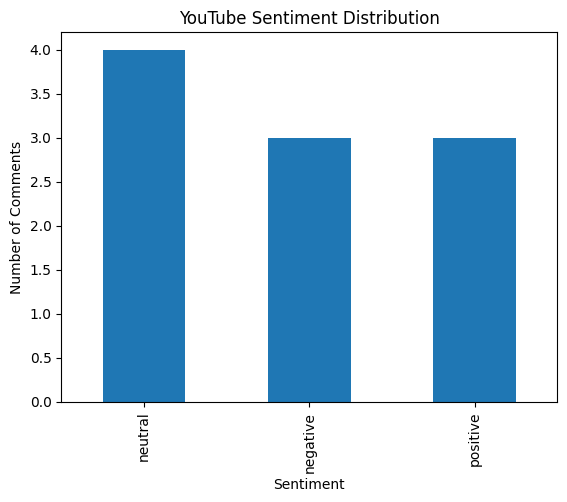

In [5]:
youtube_df['sentiment_label'].value_counts().plot(kind='bar', title="YouTube Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

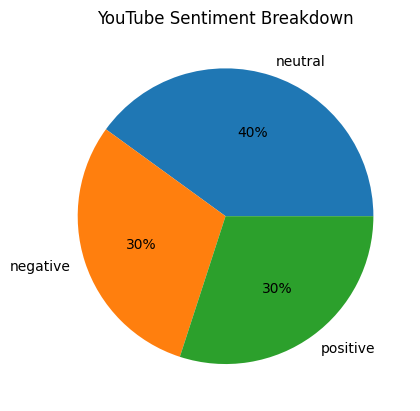

In [6]:
youtube_df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="YouTube Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [7]:
youtube_df.to_csv('youtube_sentiment.csv', index=False)